In [13]:
import pandas as pd
import os
import ast
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
folder = "Data"
df = pd.concat([pd.read_csv(os.path.join(folder, f)) for f in os.listdir(folder) if f.endswith(".csv")], ignore_index=True) # Concat toutes les data dans un seul df

In [31]:
df.head()

,resource_state,athlete,name,distance,moving_time,elapsed_time,total_elevation_gain,type,sport_type,workout_type,...,hide_from_home,device_name,embed_token,similar_activities,available_zones,average_watts,device_watts,kilojoules,message,errors
0,3,"{'id': 111468957, 'resource_state': 1}",Course à pied le midi,5003.5,1791,1791,51.0,Run,Run,0.0,...,False,Garmin Forerunner 745,1f8152105eec3deb87296b1d8ff8f1c84409adb0,"{'effort_count': 1, 'average_speed': 2.7936906...",[],NaN,NaN,NaN,NaN,NaN
1,3,"{'id': 111468957, 'resource_state': 1}",Sortie vélo dans l'après-midi,0.0,1802,1802,0.0,Ride,Ride,NaN,...,False,Garmin Forerunner 745,10e797263712099820b5e1fccac7349a191c4d5f,NaN,[],NaN,NaN,NaN,NaN,NaN
2,3,"{'id': 111468957, 'resource_state': 1}",Course à pied dans l'après-midi,8128.1,2833,2841,69.0,Run,Run,0.0,...,False,Garmin Forerunner 745,b4d6435c8018a7e321c63b0b3a58613a01411183,"{'effort_count': 2, 'average_speed': 2.9518188...",[],NaN,NaN,NaN,NaN,NaN
3,3,"{'id': 111468957, 'resource_state': 1}",Course à pied dans l'après-midi,7594.3,2595,2595,57.0,Run,Run,0.0,...,False,Garmin Forerunner 745,19101f6e13f05eaef1bcda5d332b9c52e4b53de5,"{'effort_count': 1, 'average_speed': 2.9265124...",[],NaN,NaN,NaN,NaN,NaN
4,3,"{'id': 111468957, 'resource_state': 1}",Sortie vélo dans l'après-midi,18449.2,2673,2910,254.0,Ride,Ride,NaN,...,False,Garmin Forerunner 745,20233506de638190d0b216d770a11388d4a13d17,NaN,[],123.2,False,329.3,NaN,NaN


In [32]:
print(df.columns)

Index(['resource_state', 'athlete', 'name', 'distance', 'moving_time',
       'elapsed_time', 'total_elevation_gain', 'type', 'sport_type',
       'workout_type', 'id', 'start_date', 'start_date_local', 'timezone',
       'utc_offset', 'location_city', 'location_state', 'location_country',
       'achievement_count', 'kudos_count', 'comment_count', 'athlete_count',
       'photo_count', 'map', 'trainer', 'commute', 'manual', 'private',
       'visibility', 'flagged', 'gear_id', 'start_latlng', 'end_latlng',
       'average_speed', 'max_speed', 'average_cadence', 'average_temp',
       'has_heartrate', 'average_heartrate', 'max_heartrate',
       'heartrate_opt_out', 'display_hide_heartrate_option', 'elev_high',
       'elev_low', 'upload_id', 'upload_id_str', 'external_id',
       'from_accepted_tag', 'pr_count', 'total_photo_count', 'has_kudoed',
       'description', 'calories', 'perceived_exertion',
       'prefer_perceived_exertion', 'segment_efforts', 'splits_metric',
       'spli

In [33]:
print(len(df))

437


In [ ]:
df = df.drop(columns = ['photo_count', 'from_accepted_tag', 'achievement_count', 'location_state', 'kudos_count', 'comment_count', 'map', 'trainer', 'commute', 'flagged', 'start_latlng', 'end_latlng',
                        'upload_id', 'upload_id_str', 'external_id', 'from_accepted_tag', 'pr_count', 'total_photo_count', 'has_kudoed', 'location_country', 'location_city', 'name', 'start_date_local',
                        'display_hide_heartrate_option', 'elapsed_time', 'utc_offset', 'device_watts', 'workout_type', 'type', 'resource_state', 'timezone', 'elev_low', 'elev_high', 'manual', 'kilojoules',
                        'perceived_exertion', 'prefer_perceived_exertion', 'segment_efforts', 'description', 'stats_visibility', 'hide_from_home', 'photos', 'similar_activities', 'device_name', 'message',
                        'gear', 'gear_id', 'embed_token'

       ])

In [35]:
df['athlete'] = df['athlete'].apply(ast.literal_eval) # colonne pas bien formatée (ça devrait être un dictionnaire mais c'est un str)
df = df.rename(columns = {'athlete' : 'athlete_id', 'id' : 'activity_id'})
df['athlete_id'] = df['athlete_id'][0]['id']
df['moving_time'] = df['moving_time'] / 60 # c'est en secondes de base donc on passe en minutes
df['average_speed_km_h'] = df['average_speed'] * 3.6 # vitesse en km/h
df['average_speed_min_km'] = df['moving_time'] / df['distance'] * 1000 # vitesse en min/km
df['average_cadence'] = df['average_cadence'] * 2

In [36]:
unique_counts = df.nunique().sort_values(ascending=False)
df_unique = pd.DataFrame({'Colonne': unique_counts.index, 'Valeurs Uniques': unique_counts.values})
print(df_unique)

                 Colonne  Valeurs Uniques
0            activity_id              437
1             start_date              437
2   average_speed_min_km              420
3            moving_time              412
4               distance              401
5              max_speed              375
6     average_speed_km_h              356
7          average_speed              356
8      average_heartrate              292
9   total_elevation_gain              151
10                  laps               90
11           embed_token               90
12              calories               84
13         splits_metric               83
14       splits_standard               83
15          best_efforts               78
16       average_cadence               76
17         max_heartrate               64
18         average_watts               33
19          average_temp               23
20         athlete_count               13
21               gear_id                6
22                  gear          

In [37]:
df_values = df["athlete_id"].value_counts().reset_index()
df_values.columns = ["Valeur", "Occurrences"]
print(df_values)

      Valeur  Occurrences
0  111468957          437


In [ ]:
df['start_date'] = pd.to_datetime(df['start_date'])

# Trier les données par athlète et par date
df = df.sort_values(by=['athlete_id', 'start_date'])

# Fonction pour calculer la distance cumulée pour un sport donné
def cumulative_distance(df, sport):
    return df.groupby('athlete_id').apply(lambda x: x.loc[x['sport_type'] == sport, 'distance'].cumsum()).reset_index(level=0, drop=True)

# Appliquer la fonction pour chaque sport
df['cumulative_distance_run'] = cumulative_distance(df, 'Run')
df['cumulative_distance_ride'] = cumulative_distance(df, 'Ride')
df['cumulative_distance_swim'] = cumulative_distance(df, 'Swim')

In [133]:
df_run = df[df['sport_type'] == 'Run']
df_bike = df[df['sport_type'] == 'Ride']
df_swim = df[df['sport_type'] == 'Swim']
df_workout = df[df['sport_type'] == 'Workout']

In [134]:
df_run = df_run.drop(columns = ['visibility', 'private', 'sport_type'])
df_bike = df_bike.drop(columns = ['visibility', 'private', 'sport_type'])
df_swim = df_swim.drop(columns = ['visibility', 'private', 'sport_type'])
df_workout = df_workout.drop(columns = ['visibility', 'private', 'sport_type'])

## #1 Running activites analysis ###

### Univariate analysis

In [135]:
df_run.dtypes

athlete_id                            int64
distance                            float64
moving_time                         float64
total_elevation_gain                float64
activity_id                           int64
start_date              datetime64[ns, UTC]
athlete_count                         int64
gear_id                              object
average_speed                       float64
max_speed                           float64
average_cadence                     float64
average_temp                        float64
has_heartrate                          bool
average_heartrate                   float64
max_heartrate                       float64
heartrate_opt_out                      bool
average_watts                       float64
average_speed_km_h                  float64
average_speed_min_km                float64
total_distance_run                  float64
total_distance_ride                 float64
total_distance_swim                 float64
dtype: object

In [136]:
unique_counts_run = df_run.nunique().sort_values(ascending=False)
df_unique_run = pd.DataFrame({'Colonne': unique_counts_run.index, 'Valeurs Uniques': unique_counts_run.values})
print(df_unique_run)

                 Colonne  Valeurs Uniques
0            activity_id              338
1             start_date              338
2   average_speed_min_km              338
3               distance              336
4            moving_time              319
5              max_speed              309
6          average_speed              277
7     average_speed_km_h              277
8      average_heartrate              208
9   total_elevation_gain              120
10       average_cadence               72
11         max_heartrate               51
12          average_temp               22
13         athlete_count               13
14               gear_id                5
15         has_heartrate                2
16   total_distance_ride                1
17    total_distance_run                1
18            athlete_id                1
19     heartrate_opt_out                1
20   total_distance_swim                1
21         average_watts                0


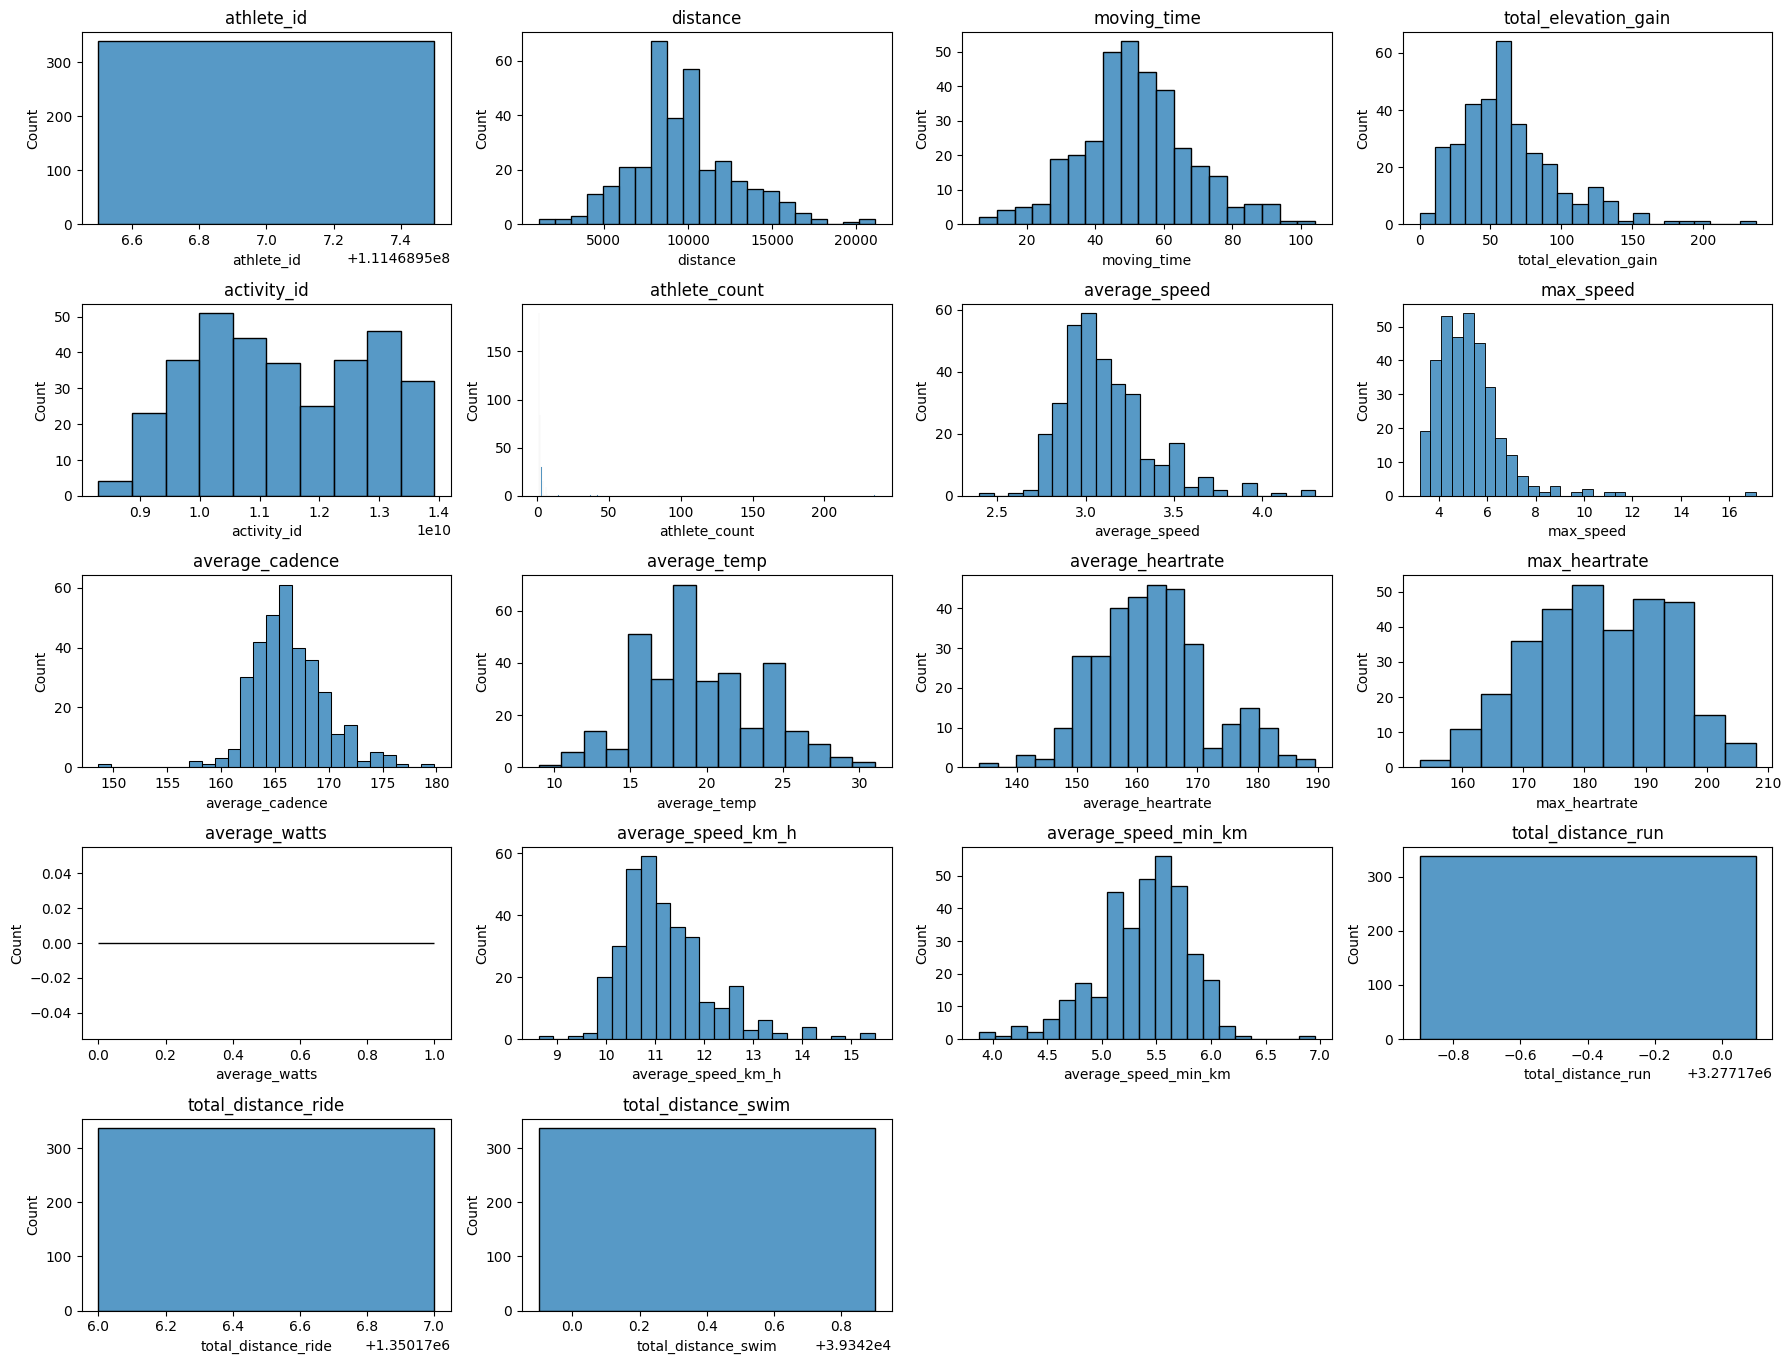

In [137]:
numerical_var = df_run.select_dtypes(include=['number'])

fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(numerical_var.columns, 1):
    plt.subplot(6, 4, index)
    sns.histplot(df_run[col], kde=False)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

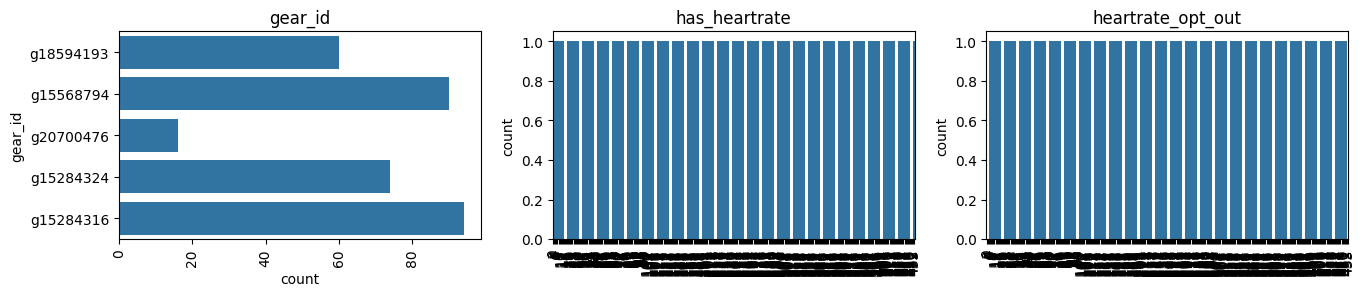

In [ ]:
categorical_var = df_run.select_dtypes(exclude=['number'])
categorical_var = categorical_var.drop(columns=['start_date']) # pas ouf pour avec ces data, juste gear_id d'intéressant
fig = plt.figure(figsize=(18, 16))

for index, col in enumerate(categorical_var.columns, 1):
    plt.subplot(6, 4, index)
    sns.countplot(df_run[col])
    plt.xticks(rotation = 90)
    plt.title(col)

fig.tight_layout(pad=1.0)
plt.show()

### Bivariate analysis

<Axes: >

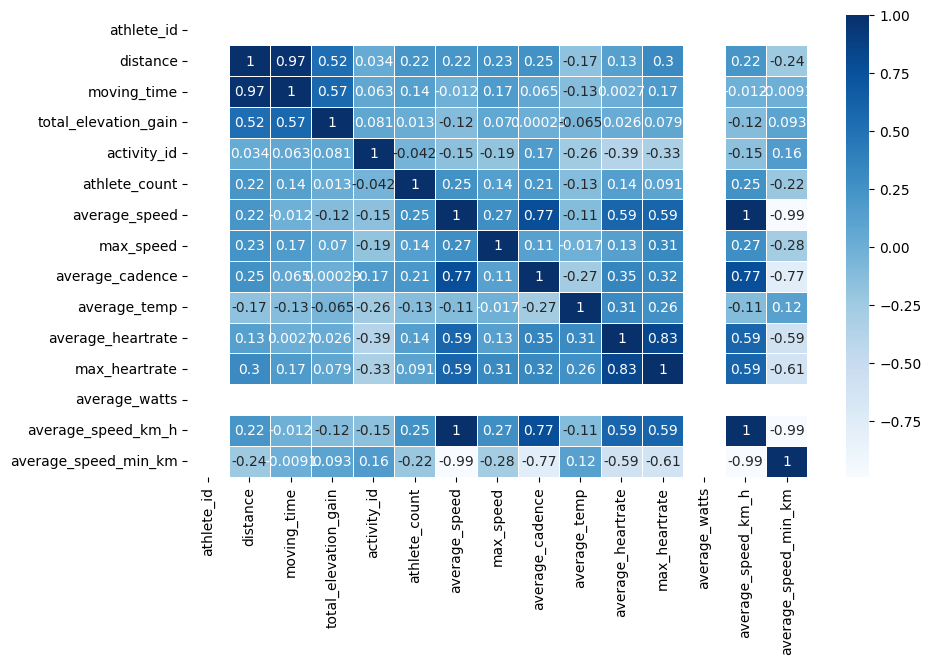

In [ ]:
plt.figure(figsize=(10,6))
correlation = numerical_var.corr()
sns.heatmap(correlation, linewidths=0.5, cmap='Blues', annot=True)